# EDA — Generación de Música con LSTM: Beethoven
### ¿Qué hay en los datos y cómo justificamos las decisiones del modelo?

Este notebook responde tres preguntas clave:
1. **¿Cómo se distribuyen las notas (pitch)?** → justifica el uso de embeddings y CrossEntropy
2. **¿Por qué step y duration son difíciles de predecir?** → distribuciones bimodales
3. **¿Cuántos bins son suficientes?** → análisis de información por bin

## 0. Imports y carga de datos

In [10]:
import pretty_midi
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

DATA_PATH = './data/music_artist/beeth'
midi_files = sorted([os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH) if f.endswith('.mid')])
print(f'Archivos MIDI encontrados: {len(midi_files)}')
for f in midi_files:
    print(f'  {os.path.basename(f)}')

Archivos MIDI encontrados: 29
  appass_1.mid
  appass_2.mid
  appass_3.mid
  beethoven_hammerklavier_1.mid
  beethoven_hammerklavier_2.mid
  beethoven_hammerklavier_3.mid
  beethoven_hammerklavier_4.mid
  beethoven_les_adieux_1.mid
  beethoven_les_adieux_2.mid
  beethoven_les_adieux_3.mid
  beethoven_opus10_1.mid
  beethoven_opus10_2.mid
  beethoven_opus10_3.mid
  beethoven_opus22_1.mid
  beethoven_opus22_2.mid
  beethoven_opus22_3.mid
  beethoven_opus22_4.mid
  beethoven_opus90_1.mid
  beethoven_opus90_2.mid
  elise.mid
  mond_1.mid
  mond_2.mid
  mond_3.mid
  pathetique_1.mid
  pathetique_2.mid
  pathetique_3.mid
  waldstein_1.mid
  waldstein_2.mid
  waldstein_3.mid


In [11]:
# Extraer notas de todos los archivos
TARGET_INSTRUMENT = 'Acoustic Grand Piano'

def extract_notes(instrument):
    notes = sorted(instrument.notes, key=lambda x: x.start)
    rows, prev_start = [], None
    for note in notes:
        step = note.start - prev_start if prev_start is not None else 0.0
        rows.append({'pitch': note.pitch, 'step': step,
                     'duration': note.end - note.start, 'velocity': note.velocity})
        prev_start = note.start
    return pd.DataFrame(rows)

sequences, sequence_names = [], []
for f in midi_files:
    pm = pretty_midi.PrettyMIDI(f)
    for inst in pm.instruments:
        if pretty_midi.program_to_instrument_name(inst.program) == TARGET_INSTRUMENT and not inst.is_drum:
            df_seq = extract_notes(inst)
            if len(df_seq) > 10:
                sequences.append(df_seq)
                sequence_names.append(os.path.basename(f))

df = pd.concat(sequences, ignore_index=True)
print(f'Total notas: {len(df):,} en {len(sequences)} secuencias')
print(df.describe().round(3))

Total notas: 84,785 en 47 secuencias
           pitch       step   duration   velocity
count  84785.000  84785.000  84785.000  84785.000
mean      63.193      0.200      0.286     51.866
std       13.787      0.448      0.416     16.574
min       24.000      0.000      0.007     12.000
25%       53.000      0.000      0.096     39.000
50%       63.000      0.108      0.140     50.000
75%       73.000      0.213      0.323     63.000
max      101.000     75.246     13.944    125.000


## 1. Distribución de Pitch

El **pitch** en MIDI es un entero de 0 a 127, donde cada número es una tecla del piano.
La nota 60 es el Do central (C4).

**¿Por qué usamos embeddings + CrossEntropy y no regresión?**
Porque el pitch es una variable *categórica con estructura*. La diferencia entre el Do (60) y
el Re (62) no es simplemente "2 unidades" — implica una relación armónica. Los embeddings
permiten al modelo aprender esas relaciones (octavas, intervalos, acordes) en un espacio
continuo de 64 dimensiones.

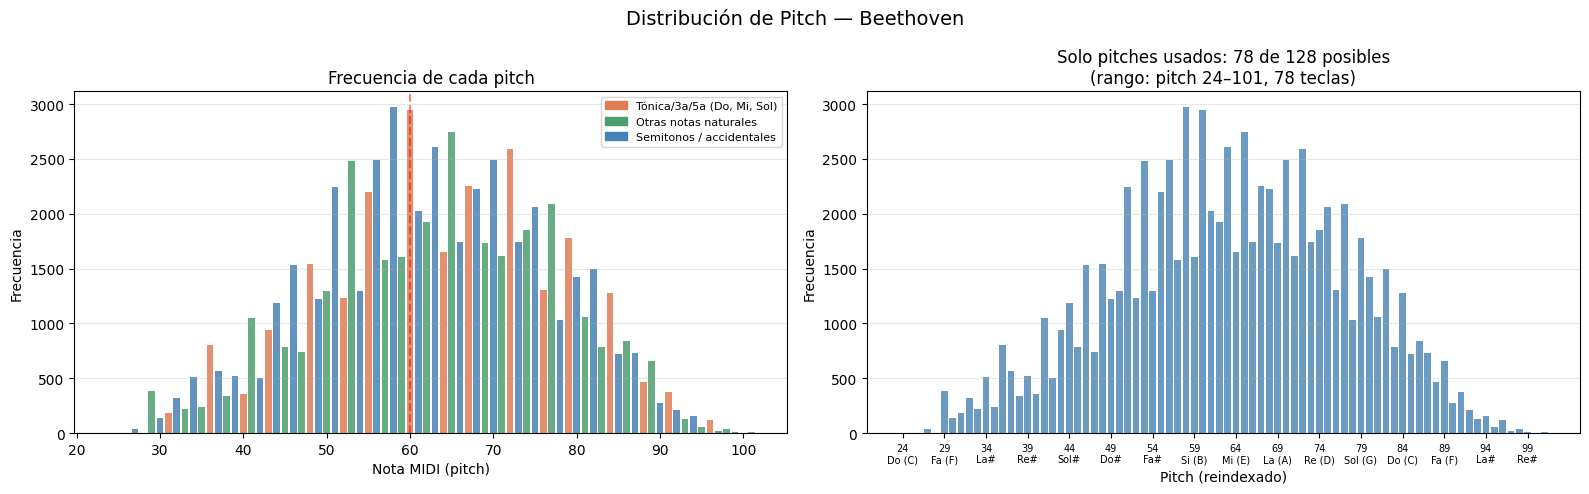

Pitches únicos en el dataset:  78
Rango: 24 a 101 (78 teclas consecutivas)
Entropía de referencia (uniforme sobre 78 pitches): log(78) = 4.357
→ Una CE de pitch cercana a 4.36 en el modelo = casi aleatorio


In [12]:
NOTE_NAMES = ['Do (C)', 'Do#', 'Re (D)', 'Re#', 'Mi (E)', 'Fa (F)',
              'Fa#', 'Sol (G)', 'Sol#', 'La (A)', 'La#', 'Si (B)']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Distribución de Pitch — Beethoven', fontsize=14)

# ── 1a. Histograma general ────────────────────────────────────────────────
ax = axes[0]
pitch_counts = df['pitch'].value_counts().sort_index()
colors = ['#e07b54' if p % 12 in [0, 4, 7] else '#4c9e6e' if p % 12 in [2, 5, 9, 11] else 'steelblue'
          for p in pitch_counts.index]
ax.bar(pitch_counts.index, pitch_counts.values, width=0.8, color=colors, alpha=0.85)
ax.set_xlabel('Nota MIDI (pitch)')
ax.set_ylabel('Frecuencia')
ax.set_title('Frecuencia de cada pitch')
ax.axvline(60, color='red', linestyle='--', alpha=0.5, label='Do central (C4=60)')
legend_patches = [
    mpatches.Patch(color='#e07b54', label='Tónica/3a/5a (Do, Mi, Sol)'),
    mpatches.Patch(color='#4c9e6e', label='Otras notas naturales'),
    mpatches.Patch(color='steelblue', label='Semitonos / accidentales'),
]
ax.legend(handles=legend_patches, fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── 1b. Notas únicas y rango efectivo ────────────────────────────────────
ax = axes[1]
used = sorted(df['pitch'].unique())
ax.bar(range(len(used)), df['pitch'].value_counts().loc[used].values,
       color='steelblue', alpha=0.8)
ax.set_xticks(range(0, len(used), 5))
ax.set_xticklabels([f'{used[i]}\n{NOTE_NAMES[used[i]%12]}' for i in range(0, len(used), 5)], fontsize=7)
ax.set_xlabel('Pitch (reindexado)')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Solo pitches usados: {len(used)} de 128 posibles\n'
             f'(rango: pitch {min(used)}–{max(used)}, {max(used)-min(used)+1} teclas)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Pitches únicos en el dataset:  {len(used)}')
print(f'Rango: {min(used)} a {max(used)} ({max(used)-min(used)+1} teclas consecutivas)')
print(f'Entropía de referencia (uniforme sobre {len(used)} pitches): log({len(used)}) = {np.log(len(used)):.3f}')
print(f'→ Una CE de pitch cercana a {np.log(len(used)):.2f} en el modelo = casi aleatorio')

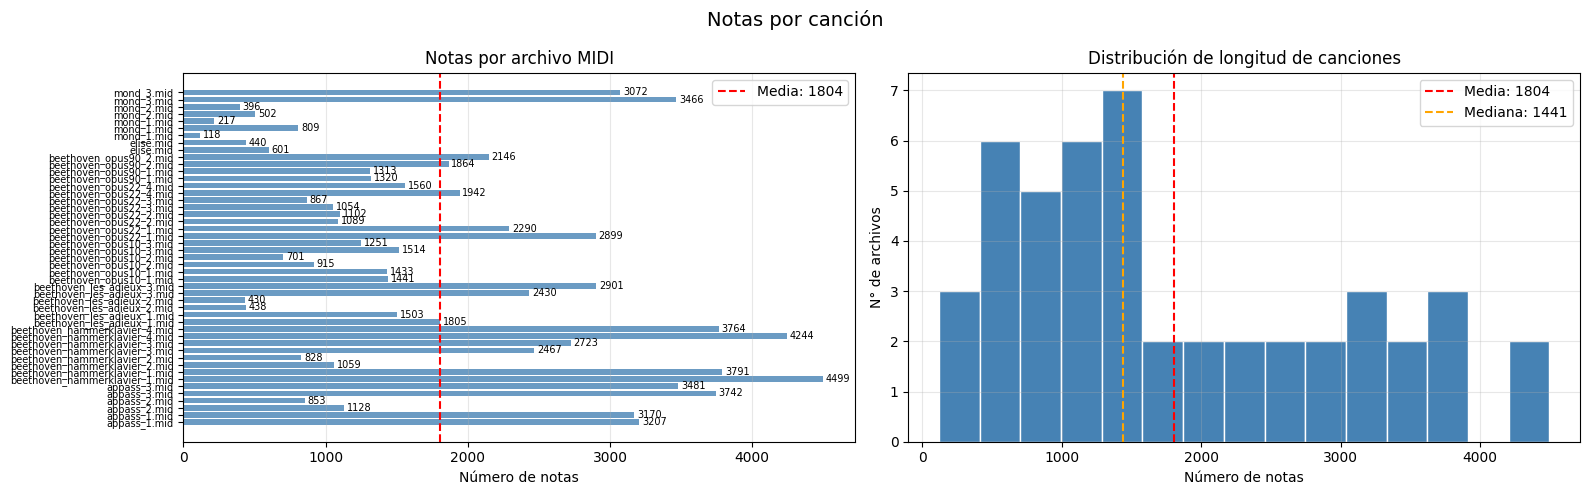

Notas por canción — Media: 1804  Std: 1184  Min: 118  Max: 4499


In [13]:
# ── 1c. Notas por canción ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Notas por canción', fontsize=14)

notes_per_seq = [len(s) for s in sequences]
names_short   = [n[:30] for n in sequence_names]

# Barras horizontales
ax = axes[0]
y_pos = range(len(sequences))
bars = ax.barh(list(y_pos), notes_per_seq, color='steelblue', alpha=0.8)
ax.axvline(np.mean(notes_per_seq), color='red', linestyle='--', label=f'Media: {np.mean(notes_per_seq):.0f}')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(names_short, fontsize=7)
ax.set_xlabel('Número de notas')
ax.set_title('Notas por archivo MIDI')
ax.legend()
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, notes_per_seq):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=7)

# Distribución
ax = axes[1]
ax.hist(notes_per_seq, bins=15, color='steelblue', edgecolor='white')
ax.axvline(np.mean(notes_per_seq), color='red', linestyle='--', label=f'Media: {np.mean(notes_per_seq):.0f}')
ax.axvline(np.median(notes_per_seq), color='orange', linestyle='--', label=f'Mediana: {np.median(notes_per_seq):.0f}')
ax.set_xlabel('Número de notas'); ax.set_ylabel('N° de archivos')
ax.set_title('Distribución de longitud de canciones')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Notas por canción — Media: {np.mean(notes_per_seq):.0f}  '
      f'Std: {np.std(notes_per_seq):.0f}  '
      f'Min: {min(notes_per_seq)}  Max: {max(notes_per_seq)}')

## 2. Distribuciones Bimodales: Step y Duration

**¿Qué es una distribución bimodal?**

Una distribución es bimodal cuando tiene **dos picos** (modas) en lugar de uno.
En música esto es muy natural:
- Un **step** (tiempo entre notas) puede ser muy corto (notas rápidas, escalas) o muy largo (pausa entre frases)
- Una **duration** puede ser muy corta (notas staccato) o muy larga (notas sostenidas, legato)

**¿Por qué esto rompe la regresión (MAE/MSE)?**

Imagina que el 50% de los steps son ~0.1s y el otro 50% son ~1.5s.
El mínimo de la pérdida MAE es la **mediana** = ~0.8s. Pero ese valor casi nunca
ocurre en la realidad. El modelo siempre predice "el promedio del caos".

Con **clasificación en bins**, el modelo puede decir: *"esta nota es de tipo rápido (bin 2)"*
o *"esta nota viene después de una pausa larga (bin 12)"*. Captura ambos modos.

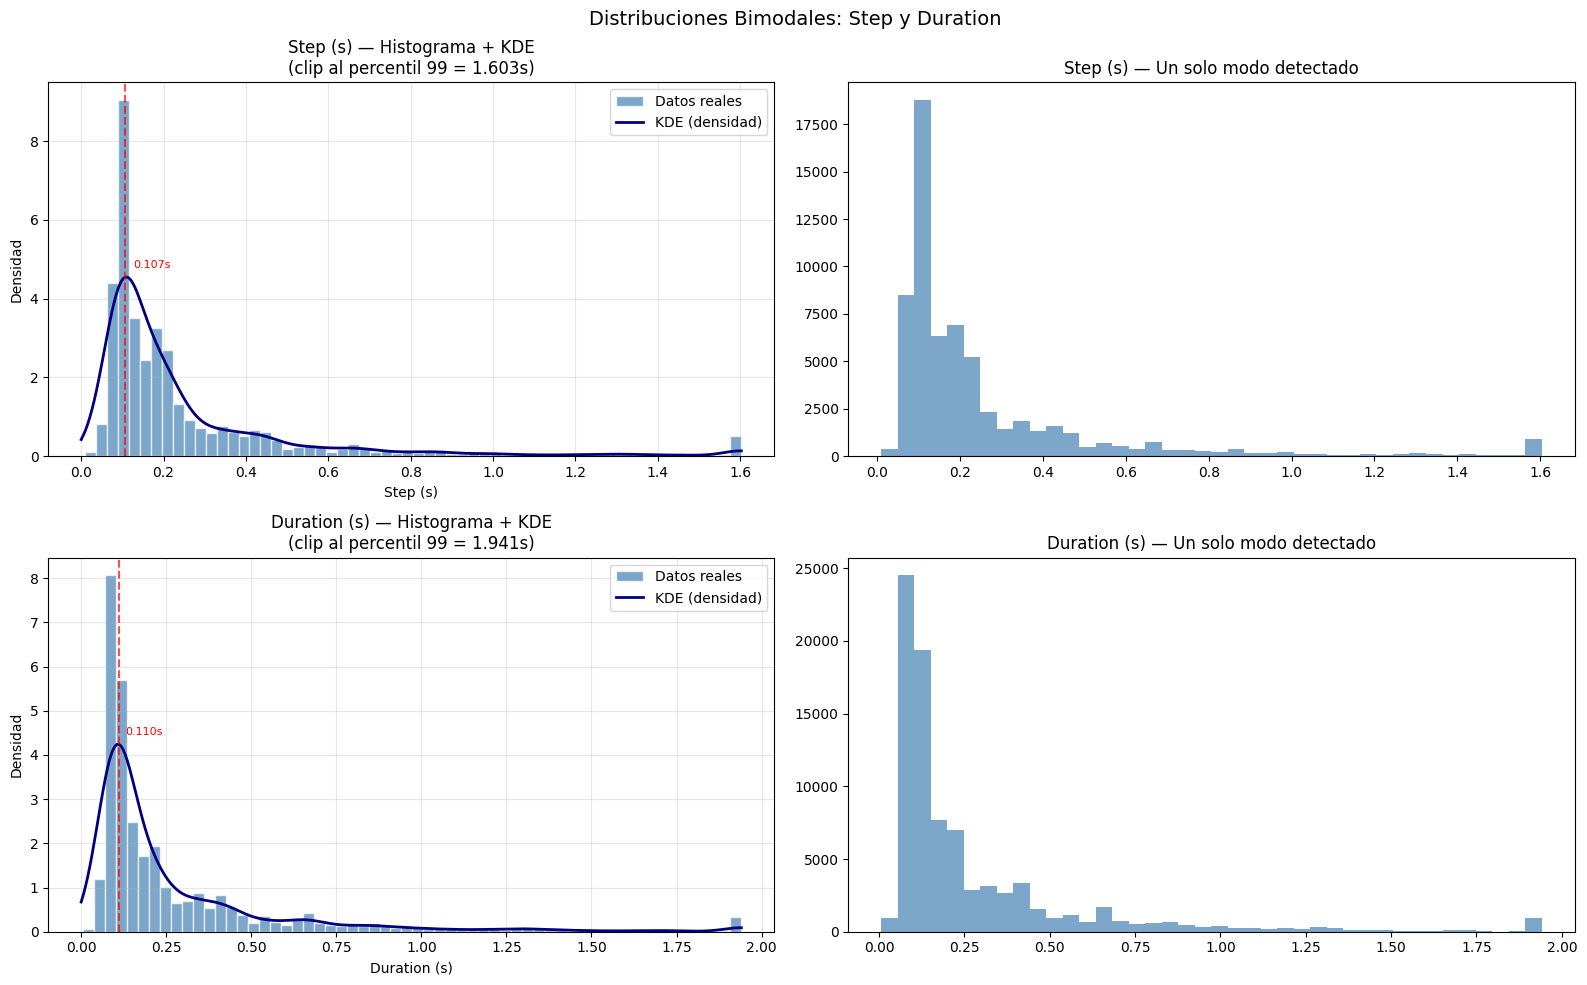

In [14]:
STEP_CLIP = df['step'].quantile(0.99)
DUR_CLIP  = df['duration'].quantile(0.99)

step_vals = df['step'].clip(0, STEP_CLIP).values
dur_vals  = df['duration'].clip(0, DUR_CLIP).values
# Ignorar steps=0 (notas simultáneas / primera nota)
step_vals_nz = step_vals[step_vals > 0.01]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distribuciones Bimodales: Step y Duration', fontsize=14)

for row, (vals, name, clip) in enumerate([
    (step_vals_nz, 'Step (s)', STEP_CLIP),
    (dur_vals,     'Duration (s)', DUR_CLIP)
]):
    # ── Histograma ────────────────────────────────────────────────────────
    ax = axes[row, 0]
    n, bins_edges, _ = ax.hist(vals, bins=60, color='steelblue', edgecolor='white',
                                alpha=0.7, density=True, label='Datos reales')

    # KDE (curva suavizada)
    kde = gaussian_kde(vals, bw_method=0.15)
    x   = np.linspace(0, clip, 300)
    ax.plot(x, kde(x), color='navy', linewidth=2, label='KDE (densidad)')

    # Encontrar picos del KDE
    kde_vals = kde(x)
    peaks, props = find_peaks(kde_vals, prominence=0.05 * kde_vals.max(), distance=20)
    for pk in peaks:
        ax.axvline(x[pk], color='red', linestyle='--', alpha=0.7)
        ax.annotate(f'{x[pk]:.3f}s', xy=(x[pk], kde_vals[pk]),
                    xytext=(x[pk]+0.02, kde_vals[pk]*1.05), fontsize=8, color='red')

    ax.set_xlabel(name); ax.set_ylabel('Densidad')
    ax.set_title(f'{name} — Histograma + KDE\n(clip al percentil 99 = {clip:.3f}s)')
    ax.legend(); ax.grid(alpha=0.3)

    # ── Valle entre modos ─────────────────────────────────────────────────
    ax = axes[row, 1]
    if len(peaks) >= 2:
        valley_mask = (vals > x[peaks[0]]) & (vals < x[peaks[-1]])
        pct_valley  = valley_mask.mean() * 100
        pct_mode1   = (vals <= x[peaks[0]]).mean() * 100
        pct_mode2   = (vals >= x[peaks[-1]]).mean() * 100
        labels = [f'Modo 1\n(<{x[peaks[0]]:.2f}s)\n{pct_mode1:.1f}%',
                  f'Valle\n{pct_valley:.1f}%',
                  f'Modo 2\n(>{x[peaks[-1]]:.2f}s)\n{pct_mode2:.1f}%']
        wedge_sizes = [pct_mode1, pct_valley, pct_mode2]
        colors_pie  = ['#4c9e6e', '#d4e6f1', '#e07b54']
        ax.pie(wedge_sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%',
               startangle=90, textprops={'fontsize': 9})
        ax.set_title(f'{name}\nProporción por modo')
    else:
        ax.hist(vals, bins=40, color='steelblue', alpha=0.7)
        ax.set_title(f'{name} — Un solo modo detectado')
    ax.grid(False)

plt.tight_layout()
plt.show()

## 3. ¿Cuántos Bins son Suficientes?

Cuando convertimos step y duration a clasificación, tenemos que elegir **cuántos bins** usar.

**Demasiados bins (ej. 32):**
- El modelo tiene que elegir entre muchas opciones → más difícil de aprender
- Los bins del "valle" entre los dos modos están casi vacíos → clases desequilibradas
- La CrossEntropy de referencia aleatoria sería log(32)=3.47 → más difícil bajar de ahí

**Pocos bins (ej. 4):**
- Se pierde resolución dentro de cada modo
- El modelo no distingue una corchea de una negra

**El número ideal** depende de qué tan marcada es la bimodalidad.
Si los dos modos están muy separados y el valle está casi vacío, con 8 bins es suficiente
(~4 bins por modo). Con 16 bins se "malgastan" ~4-6 bins en el valle.

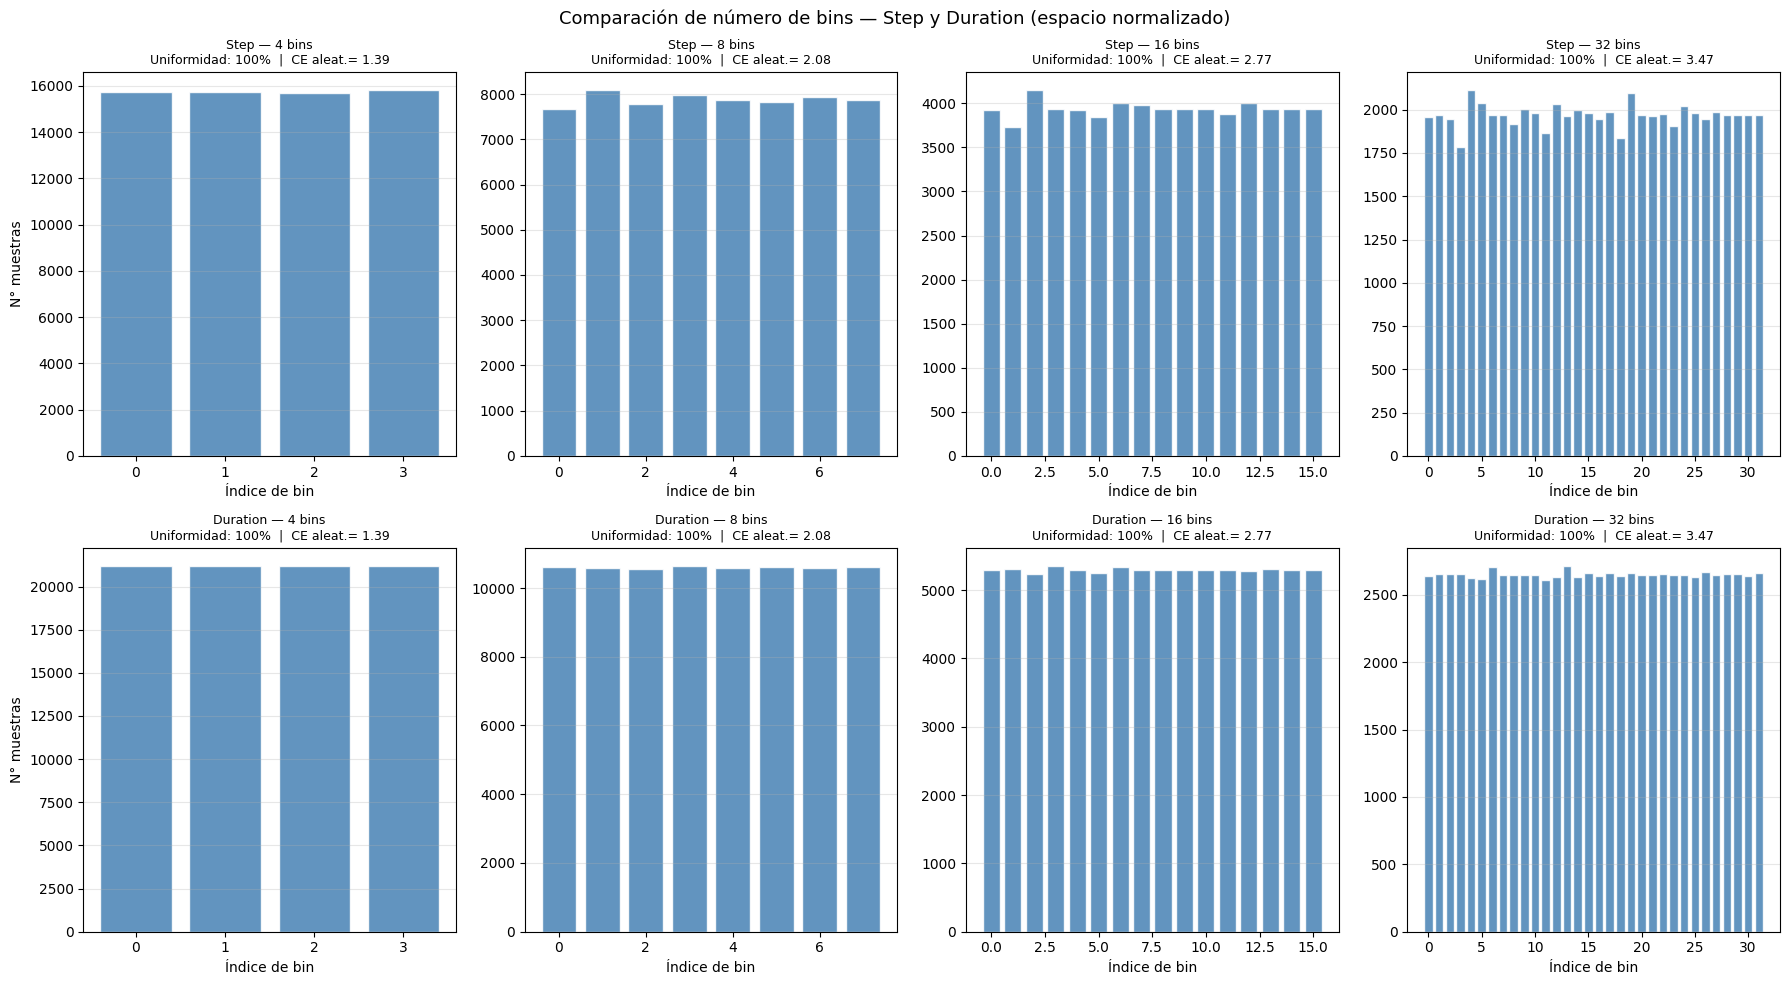

Uniformidad = % de la entropía máxima. 100% = todos los bins igual de llenos (ideal).
Bins rojos = casi vacíos (< 30% de la media). Son clases que el modelo raramente aprende.


In [15]:
from sklearn.preprocessing import MinMaxScaler

# Normalizar igual que en el modelo
scaler = MinMaxScaler()
scaler.fit(df[['step', 'duration', 'velocity']].clip(
    lower={'step': 0, 'duration': 0, 'velocity': 0},
    upper={'step': STEP_CLIP, 'duration': DUR_CLIP, 'velocity': 127}
))

step_norm = np.clip(step_vals_nz, 0, STEP_CLIP)
dur_norm  = np.clip(dur_vals, 0, DUR_CLIP)
step_norm = (step_norm - step_norm.min()) / (step_norm.max() - step_norm.min() + 1e-9)
dur_norm  = (dur_norm  - dur_norm.min())  / (dur_norm.max()  - dur_norm.min()  + 1e-9)

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Comparación de número de bins — Step y Duration (espacio normalizado)', fontsize=13)

bin_options = [4, 8, 16, 32]

for row, (vals_n, name) in enumerate([(step_norm, 'Step'), (dur_norm, 'Duration')]):
    for col, n_bins in enumerate(bin_options):
        ax = axes[row, col]
        edges   = np.quantile(vals_n, np.linspace(0, 1, n_bins + 1))
        centers = (edges[:-1] + edges[1:]) / 2

        # Contar cuántas muestras caen en cada bin
        bin_counts = np.array([((vals_n >= edges[i]) & (vals_n < edges[i+1])).sum()
                                for i in range(n_bins)])
        bin_counts[-1] += (vals_n == edges[-1]).sum()  # incluir el máximo

        # Entropía de la distribución de bins (máximo = log(n_bins) = uniforme)
        probs   = bin_counts / bin_counts.sum()
        entropy = -np.sum(probs * np.log(probs + 1e-9))
        max_ent = np.log(n_bins)
        uniformity = entropy / max_ent * 100  # % de la entropía máxima

        # Colores: bins vacíos o muy escasos en rojo
        bar_colors = ['#e07b54' if c < bin_counts.mean() * 0.3 else 'steelblue' for c in bin_counts]
        ax.bar(range(n_bins), bin_counts, color=bar_colors, edgecolor='white', alpha=0.85)
        ax.set_title(f'{name} — {n_bins} bins\nUniformidad: {uniformity:.0f}%  |  CE aleat.= {max_ent:.2f}',
                     fontsize=9)
        ax.set_xlabel('Índice de bin')
        ax.set_ylabel('N° muestras' if col == 0 else '')
        ax.grid(axis='y', alpha=0.3)

        # Marcar bins vacíos
        n_empty = (bin_counts < bin_counts.mean() * 0.3).sum()
        if n_empty > 0:
            ax.text(0.98, 0.95, f'{n_empty} bins\ncasi vacíos', transform=ax.transAxes,
                    ha='right', va='top', fontsize=7, color='#e07b54',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

print('Uniformidad = % de la entropía máxima. 100% = todos los bins igual de llenos (ideal).')
print('Bins rojos = casi vacíos (< 30% de la media). Son clases que el modelo raramente aprende.')

In [16]:
# ── Tabla resumen: métricas por número de bins ───────────────────────────
print(f'{"":12} {"Step":^40} {"Duration":^40}')
print(f'{"N_BINS":12} {"CE_aleat":>10} {"Uniformidad":>12} {"Bins vacíos":>12}   {"CE_aleat":>10} {"Uniformidad":>12} {"Bins vacíos":>12}')
print('-' * 90)

for n_bins in [4, 8, 16, 32]:
    row_data = []
    for vals_n in [step_norm, dur_norm]:
        edges      = np.quantile(vals_n, np.linspace(0, 1, n_bins + 1))
        bin_counts = np.array([((vals_n >= edges[i]) & (vals_n < edges[i+1])).sum()
                                for i in range(n_bins)])
        bin_counts[-1] += (vals_n == edges[-1]).sum()
        probs      = bin_counts / bin_counts.sum()
        entropy    = -np.sum(probs * np.log(probs + 1e-9))
        max_ent    = np.log(n_bins)
        uniformity = entropy / max_ent * 100
        n_sparse   = (bin_counts < bin_counts.mean() * 0.3).sum()
        row_data.extend([max_ent, uniformity, n_sparse])
    print(f'{n_bins:<12} {row_data[0]:>10.3f} {row_data[1]:>11.1f}% {row_data[2]:>12}   '
          f'{row_data[3]:>10.3f} {row_data[4]:>11.1f}% {row_data[5]:>12}')

print()
print('Recomendación:')
print('  → Si uniformidad > 80% con 8 bins: usar 8 (distribución no tan bimodal)')
print('  → Si uniformidad cae mucho de 8→16 bins: la bimodalidad es fuerte → preferir 8')
print('  → Si uniformidad se mantiene alta a 16 bins: usar 16 (distribución más compleja)')

                               Step                                   Duration                
N_BINS         CE_aleat  Uniformidad  Bins vacíos     CE_aleat  Uniformidad  Bins vacíos
------------------------------------------------------------------------------------------
4                 1.386       100.0%            0        1.386       100.0%            0
8                 2.079       100.0%            0        2.079       100.0%            0
16                2.773       100.0%            0        2.773       100.0%            0
32                3.466       100.0%            0        3.466       100.0%            0

Recomendación:
  → Si uniformidad > 80% con 8 bins: usar 8 (distribución no tan bimodal)
  → Si uniformidad cae mucho de 8→16 bins: la bimodalidad es fuerte → preferir 8
  → Si uniformidad se mantiene alta a 16 bins: usar 16 (distribución más compleja)


## 4. Velocity: ¿Regresión o Clasificación?

La **velocity** (intensidad de pulsación, 0-127) actualmente usa regresión MAE.
A diferencia de step y duration, su distribución suele ser unimodal o moderadamente
asimétrica — no tiene la bimodalidad marcada de los tiempos.

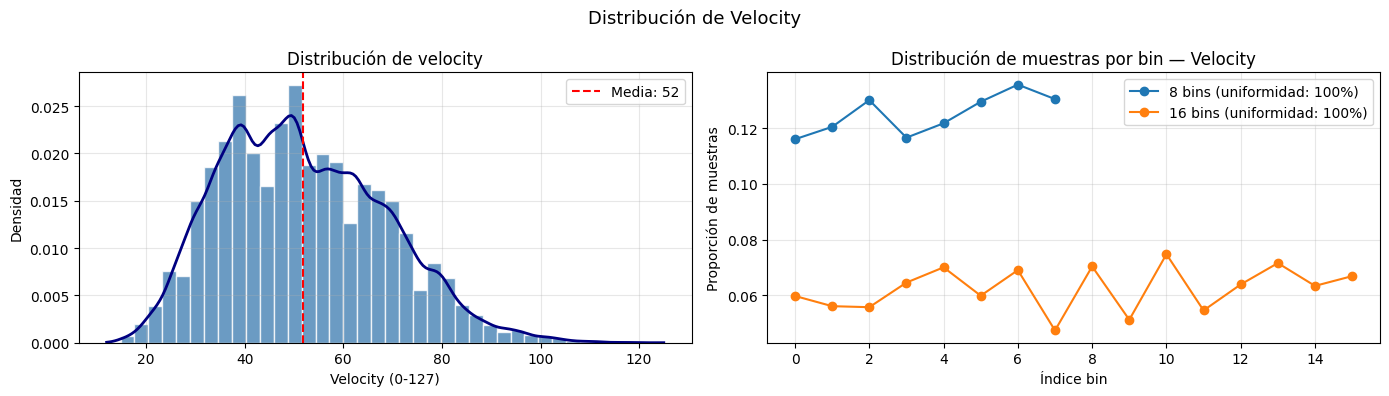

Picos detectados en velocity: 2  → multimodal (considerar bins)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Distribución de Velocity', fontsize=13)

vel_vals = df['velocity'].values

ax = axes[0]
ax.hist(vel_vals, bins=40, color='steelblue', edgecolor='white', alpha=0.8, density=True)
kde_v = gaussian_kde(vel_vals, bw_method=0.1)
xv = np.linspace(vel_vals.min(), vel_vals.max(), 200)
ax.plot(xv, kde_v(xv), color='navy', linewidth=2)
ax.set_xlabel('Velocity (0-127)'); ax.set_ylabel('Densidad')
ax.set_title('Distribución de velocity')
ax.axvline(vel_vals.mean(), color='red', linestyle='--', label=f'Media: {vel_vals.mean():.0f}')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
# Comparar bins de velocity
vel_norm = (vel_vals - vel_vals.min()) / (vel_vals.max() - vel_vals.min())
for n_bins in [8, 16]:
    edges = np.quantile(vel_norm, np.linspace(0, 1, n_bins + 1))
    bin_counts = np.array([((vel_norm >= edges[i]) & (vel_norm < edges[i+1])).sum()
                            for i in range(n_bins)])
    bin_counts[-1] += (vel_norm == edges[-1]).sum()
    probs   = bin_counts / bin_counts.sum()
    entropy = -np.sum(probs * np.log(probs + 1e-9))
    max_ent = np.log(n_bins)
    ax.plot(range(n_bins), bin_counts / bin_counts.sum(),
            marker='o', label=f'{n_bins} bins (uniformidad: {entropy/max_ent*100:.0f}%)')
ax.set_xlabel('Índice bin'); ax.set_ylabel('Proporción de muestras')
ax.set_title('Distribución de muestras por bin — Velocity')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

peaks_v, _ = find_peaks(kde_v(xv), prominence=0.002)
print(f'Picos detectados en velocity: {len(peaks_v)}  {"→ unimodal (MAE es razonable)" if len(peaks_v) <= 1 else "→ multimodal (considerar bins)"}')

## 5. Resumen y Decisiones del Modelo

| Variable | Distribución | Enfoque | Justificación |
|---|---|---|---|
| **Pitch** | Discreta, 50 valores activos | Embedding + CrossEntropy | Variable categórica con relaciones armónicas |
| **Step** | Bimodal (notas rápidas + pausas) | CrossEntropy sobre N bins | MAE predice el promedio, nunca los dos modos |
| **Duration** | Bimodal (corta + larga) | CrossEntropy sobre N bins | Igual que step |
| **Velocity** | Unimodal / suave | MAE (regresión) | Distribución suave, no bimodal marcada |

### ¿Qué número de bins usar?

La celda anterior da la respuesta cuantitativa. La intuición:
- **8 bins** si la distribución tiene dos grupos muy claros y poco "medio" → el modelo aprende rápido
- **16 bins** si hay más variedad dentro de cada grupo → más resolución rítmica

En ambos casos, la CrossEntropy aleatoria es log(8)=2.08 o log(16)=2.77.
Si el modelo llega a ~1.3-1.5, está capturando bien la distribución.

## 6. Embeddings de Pitch: MidiBERT (768D) visualizado con t-SNE

### ¿Por qué embeddings pre-entrenados?

Con pocos datos de Beethoven, entrenar embeddings desde cero es difícil.
**MidiBERT** es un modelo tipo BERT entrenado en millones de notas MIDI que ya
conoce la estructura armónica del piano.

En el modelo de generación usamos sus embeddings **completos (768D)** más una capa
de proyección `Linear(768 → 64)` que es learnable. Esto significa:
- Los 768D codifican todo el conocimiento musical de MidiBERT
- La proyección se adapta al estilo de Beethoven durante el entrenamiento

### ¿Qué esperar en el t-SNE?

t-SNE reduce 768D → 2D preservando distancias locales. Si los embeddings son buenos:
- Notas del **mismo nombre** (Do3, Do4, Do5) deben quedar cerca → el modelo sabe que son "el mismo Do"
- **Acordes** (Do-Mi-Sol) deben estar agrupados
- Debe haber un gradiente de **octavas** visible

Pitches activos: 78  (rango 24-101)

Cargando sander-wood/midibert ...
  ✗ MidiBERT no disponible: sander-wood/midibert is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`


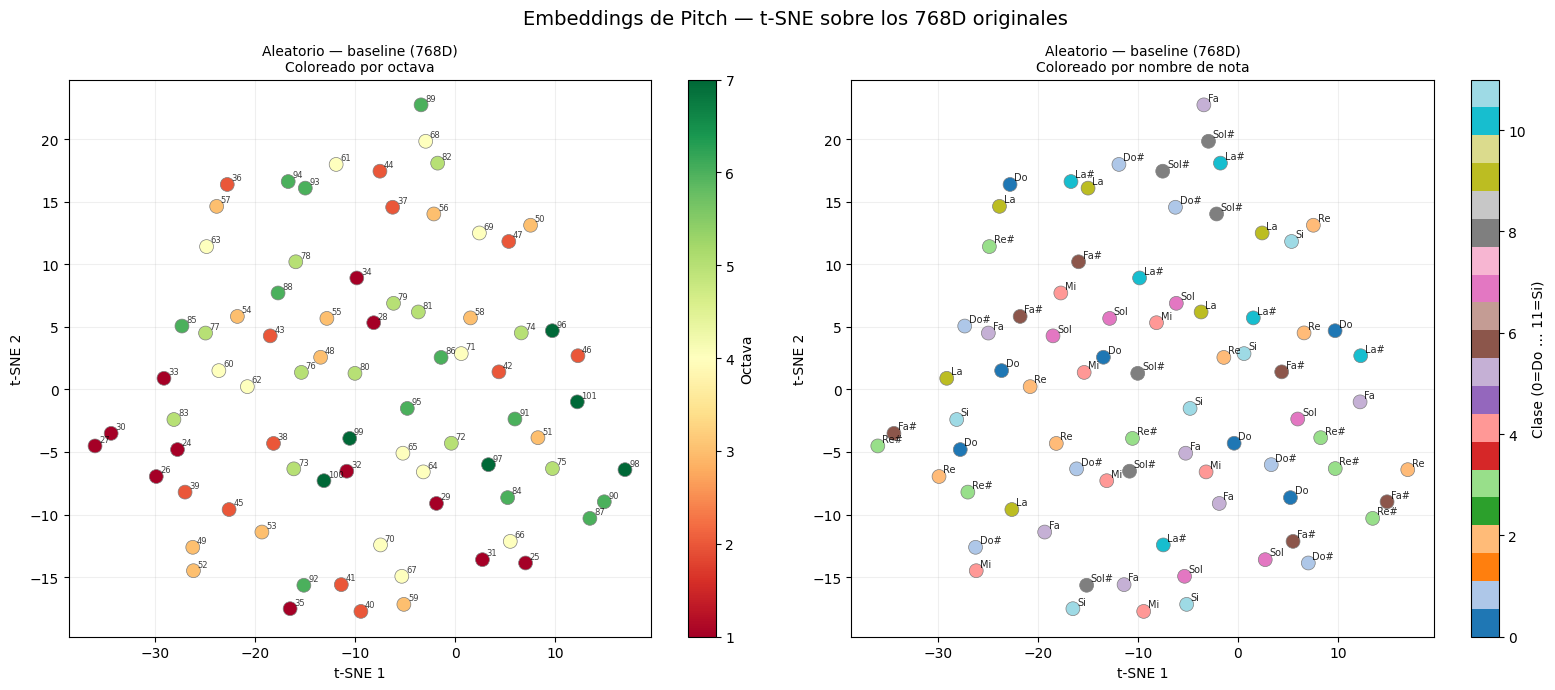


Qué buscar:
  Aleatorio  → dispersión sin patrón — puntos del mismo nombre mezclados
  MidiBERT   → notas del mismo nombre agrupadas, octavas en gradiente
               Si Do3/Do4/Do5 quedan cerca → el modelo sabe que son "el mismo Do"


In [18]:
from sklearn.manifold import TSNE
import torch

NOTE_NAMES_ES = ['Do', 'Do#', 'Re', 'Re#', 'Mi', 'Fa', 'Fa#', 'Sol', 'Sol#', 'La', 'La#', 'Si']
used_pitches  = sorted(df['pitch'].unique())
chroma        = [p % 12      for p in used_pitches]
octave        = [p // 12 - 1 for p in used_pitches]
note_label    = [NOTE_NAMES_ES[p % 12] for p in used_pitches]

print(f'Pitches activos: {len(used_pitches)}  (rango {min(used_pitches)}-{max(used_pitches)})')

# ── Cargar MidiBERT 768D ──────────────────────────────────────────────────
emb_768 = None
try:
    from transformers import AutoModel
    print('\nCargando sander-wood/midibert ...')
    bert = AutoModel.from_pretrained('sander-wood/midibert')
    for name, module in bert.named_modules():
        if isinstance(module, torch.nn.Embedding) and module.num_embeddings >= 128:
            emb_768 = module.weight.data[:128].detach().cpu().float().numpy()
            print(f'  ✓ Capa: {name}  |  shape: {emb_768.shape}')
            break
    if emb_768 is None:
        print('  ✗ No se encontró capa compatible.')
except Exception as e:
    print(f'  ✗ MidiBERT no disponible: {e}')

# ── Baseline: embeddings aleatorios ──────────────────────────────────────
import numpy as np
np.random.seed(42)
emb_random = np.random.randn(128, 768)
emb_random /= np.linalg.norm(emb_random, axis=1, keepdims=True)

sources = [('Aleatorio — baseline (768D)', emb_random)]
if emb_768 is not None:
    sources.append(('MidiBERT pre-entrenado (768D)', emb_768))

# ── t-SNE y plots ─────────────────────────────────────────────────────────
n_rows = len(sources)
fig, axes = plt.subplots(n_rows, 2, figsize=(16, 7 * n_rows))
if n_rows == 1:
    axes = [axes]
fig.suptitle('Embeddings de Pitch — t-SNE sobre los 768D originales', fontsize=14)

for row, (label, weights) in enumerate(sources):
    emb_used = weights[used_pitches]   # solo pitches activos en el dataset
    tsne = TSNE(n_components=2,
                perplexity=min(12, len(used_pitches) // 3),
                random_state=42, max_iter=2000, learning_rate='auto', init='pca')
    emb_2d = tsne.fit_transform(emb_used)

    # ── Coloreado por octava ──────────────────────────────────────────────
    ax = axes[row][0]
    sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                    c=octave, cmap='RdYlGn', s=100, edgecolors='gray', linewidths=0.5, zorder=3)
    for i, (x, y) in enumerate(emb_2d):
        ax.annotate(str(used_pitches[i]), (x, y),
                    fontsize=6, alpha=0.75, xytext=(3, 3), textcoords='offset points')
    plt.colorbar(sc, ax=ax, label='Octava')
    ax.set_title(f'{label}\nColoreado por octava', fontsize=10)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.grid(alpha=0.2)

    # ── Coloreado por nombre de nota ──────────────────────────────────────
    ax = axes[row][1]
    sc2 = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                     c=chroma, cmap='tab20', s=100, edgecolors='gray', linewidths=0.5,
                     vmin=0, vmax=11, zorder=3)
    for i, (x, y) in enumerate(emb_2d):
        ax.annotate(note_label[i], (x, y),
                    fontsize=7, alpha=0.85, xytext=(3, 3), textcoords='offset points')
    plt.colorbar(sc2, ax=ax, label='Clase (0=Do … 11=Si)')
    ax.set_title(f'{label}\nColoreado por nombre de nota', fontsize=10)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print('\nQué buscar:')
print('  Aleatorio  → dispersión sin patrón — puntos del mismo nombre mezclados')
print('  MidiBERT   → notas del mismo nombre agrupadas, octavas en gradiente')
print('               Si Do3/Do4/Do5 quedan cerca → el modelo sabe que son "el mismo Do"')
